# SpMV kernel version comparison — random matrices

Compares the three multicore SpMV kernels on **random** matrices swept across a
range of densities and two nonzero distributions (Uniform / PowerLaw), produced
by `profile_random_matrices.py`:

| version | kernel | bench | operator column |
|---|---|---|---|
| `multicore` | `run_spmv` | `spmv` | `spmv_{alpha}_128` |
| `multicube` | `run_spmv_multi_cube` | `spmv_multi_cube` | `spmv_multi_cube_{alpha}_128` |
| `spmv_v2` | `run_spmv_v2` | `spmv_v2` | `spmv_v2_{alpha}_128` |

Generate the data with:
```bash
make -f Makefile.spmv.mk profile_fp16_spmv_versions_random
```
CSVs are written as
`random_matrices_{distr}_{operator}_{alpha}_128_{dtype}_{density}.csv` in
`benchmarks_dir` (defaults to the current dir via `TCUSCAN_BENCHMARK_REPORT_PATH`).

The loader below derives version / distribution / density from the **file name**
and reads only the reliable fields (`size`=nnz and the last field=`time_us`), so
it tolerates partially-written files while a benchmark run is still in progress.

In [14]:
import os
import re
from glob import glob
from os.path import join

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

benchmarks_dir = "../.."

# operator group is ordered longest-first so spmv_multi_cube / spmv_v2 win over
# the bare spmv prefix. Followed by _{alpha}_128_{dtype}_{density}.csv.
rand_pattern = re.compile(
    r"random_matrices_(?P<distr>\w+?)_"
    r"(?P<operator>spmv_multi_cube|spmv_v2|spmv)_[\d.]+_128_"
    r"(?P<dtype>\w+)_(?P<density>[\d.]+)\.csv$"
)

operator_to_version = {
    "spmv": "multicore",
    "spmv_multi_cube": "multicube",
    "spmv_v2": "spmv_v2",
}

rand_rows = []
for path in sorted(glob(join(benchmarks_dir, "random_matrices_*_128_*.csv"))):
    m = rand_pattern.search(os.path.basename(path))
    if not m:
        continue
    version = operator_to_version[m["operator"]]
    for line in open(path, encoding="UTF-8"):
        fields = line.strip().split(",")
        if not fields or fields[0] == "operator" or len(fields) < 3:
            continue  # header / blank / truncated line
        try:
            nnz = int(fields[2])
            time_us = float(fields[-1])
        except ValueError:
            continue  # partially-written row
        rand_rows.append(
            {
                "version": version,
                "distr": m["distr"],
                "density": float(m["density"]),
                "nnz": nnz,
                "time_us": time_us,
            }
        )

if not rand_rows:
    print("WARNING: no random-matrix data found (benchmarks may still be running)")
    rand_df = pd.DataFrame(
        columns=["version", "distr", "density", "nnz", "time_us"]
    )
else:
    rand_df = pd.DataFrame(rand_rows).sort_values(["distr", "density", "nnz"])
rand_df.head(20)

,version,distr,density,nnz,time_us
0,multicore,PowerLaw,0.0001,655,627.52
108,multicube,PowerLaw,0.0001,655,665.88
215,spmv_v2,PowerLaw,0.0001,655,717.21
1,multicore,PowerLaw,0.0001,2620,610.77
109,multicube,PowerLaw,0.0001,2620,657.57
216,spmv_v2,PowerLaw,0.0001,2620,876.62
2,multicore,PowerLaw,0.0001,5897,618.44
110,multicube,PowerLaw,0.0001,5897,664.72
217,spmv_v2,PowerLaw,0.0001,5897,924.53
3,multicore,PowerLaw,0.0001,10484,646.44


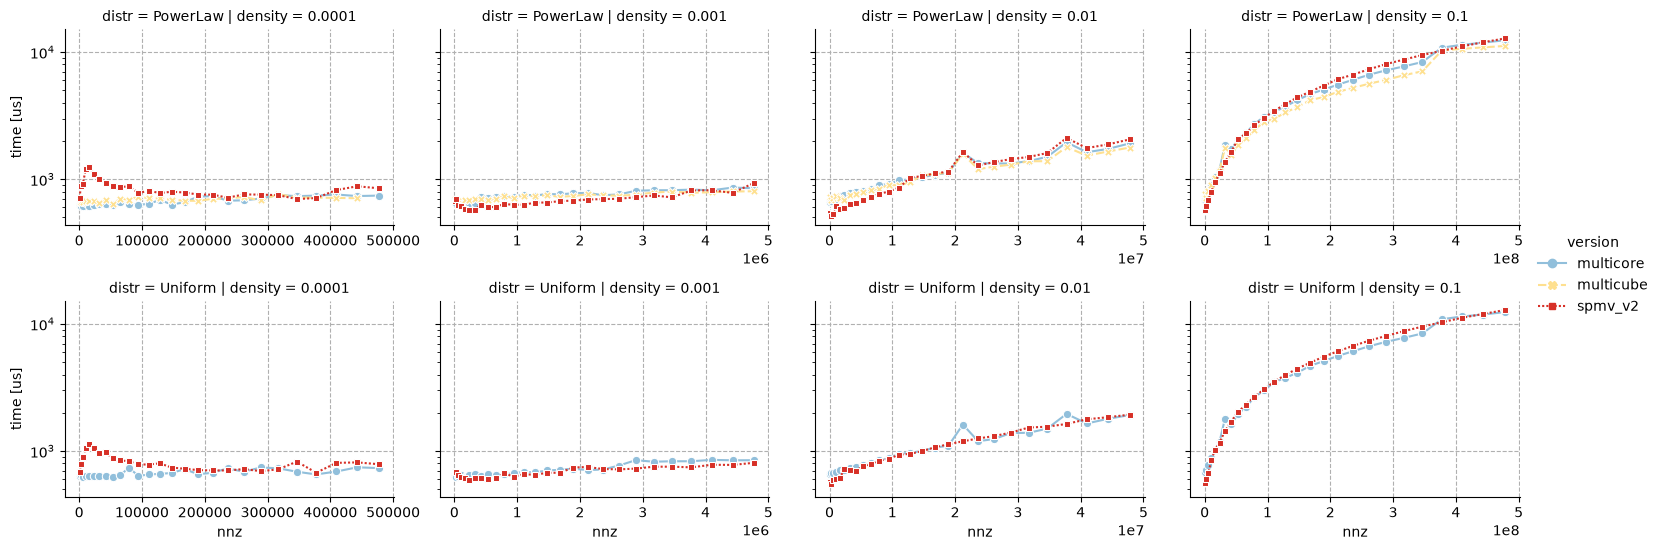

In [24]:
# time [us] vs nnz, one line per version, faceted by distribution x density.
# Log-log scale, x-axis shared across facets.
palette = ["#91bfdb", "#fee090", "#d73027"]

if rand_df.empty:
    print("No data to plot yet.")
else:
    g = sns.relplot(
        data=rand_df,
        x="nnz",
        y="time_us",
        hue="version",
        hue_order=["multicore", "multicube", "spmv_v2"],
        style="version",
        markers=True,
        kind="line",
        estimator="median",
        col="density",
        row="distr",
        palette=palette,
        facet_kws={"sharey": True, "sharex": False},
        # facet_kws={"sharey": False},
        height=2.8,
        aspect=1.4,
    )
    g.set(yscale="log")
    for ax in g.axes.flat:
        ax.grid(linestyle="--")
    g.set_axis_labels("nnz", "time [us]")
    g.savefig("spmv_versions_random_comparison.pdf", bbox_inches="tight")

In [11]:
# Speedup of each version relative to the multicore baseline, per (distr, density, nnz).
if rand_df.empty:
    print("No data to summarize yet.")
else:
    med = (
        rand_df.groupby(["distr", "density", "nnz", "version"])["time_us"]
        .median()
        .unstack()
    )
    speedup = med.div(med["multicore"], axis=0)
    speedup = speedup.rename(columns=lambda c: f"{c}_x_over_multicore")
    display(speedup)

version                     multicore_x_over_multicore  \
distr    density nnz                                     
PowerLaw 0.0001  655                               1.0   
                 2620                              1.0   
                 5897                              1.0   
                 10484                             1.0   
                 16381                             1.0   
...                                                ...   
Uniform  0.1000  346673664                         1.0   
                 377475072                         1.0   
                 409587200                         1.0   
                 443010048                         1.0   
                 477743616                         1.0   

version                     multicube_x_over_multicore  \
distr    density nnz                                     
PowerLaw 0.0001  655                          1.061130   
                 2620                         1.076625   
                 5897                         1.074833   
                 10484                        1.044737   
                 16381                        1.096643   
...                                                ...   
Uniform  0.1000  346673664                         NaN   
                 377475072                         NaN   
                 409587200                         NaN   
                 443010048                         NaN   
                 477743616                         NaN   

version                     spmv_v2_x_over_multicore  
distr    density nnz                                  
PowerLaw 0.0001  655                        1.142928  
                 2620                       1.435270  
                 5897                       1.494939  
                 10484                      1.858239  
                 16381                      2.022089  
...                                              ...  
Uniform  0.1000  346673664                  1.132470  
                 377475072                  0.946482  
                 409587200                  0.976028  
                 443010048                  1.009437  
                 477743616                  1.038541  

[216 rows x 3 columns]